In [1]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from hetero_isas.monodromy_lp import MonodromyLPDecomposer
from hetero_isas.monodromy_lp.isa import ISAHandler
from numpy.random import Philox
from qiskit.circuit.library import CXGate, CZGate, SwapGate, UnitaryGate, iSwapGate
from qiskit.quantum_info.random import random_unitary
from qiskit.synthesis.two_qubit.two_qubit_decompose import TwoQubitWeylDecomposition
from qiskit.synthesis.two_qubit.xx_decompose import XXDecomposer
from qiskit.synthesis.two_qubit.xx_decompose.utilities import EPSILON
from tqdm import tqdm
from tqdm.notebook import tqdm
from weylchamber import WeylChamber, c1c2c3

generator = Philox(0)

%matplotlib inline

In [2]:
isa_handler = ISAHandler(
    [
        CXGate(),
        CXGate().power(1 / 2),
        CXGate().power(1 / 3),
    ],
    [1.0, 1 / 2, 1 / 3],
    ["cx", "sq[2]cx", "sq[3]cx"],
)
mono_lp_decomposer = MonodromyLPDecomposer(isa_handler)

In [3]:
strengths = {
    1.5707963267948966: 1.01e-10,  # cx
    0.7853981633974483: 5.1000000000000005e-11,  # cx2
    0.5235987755982988: 3.433333333333333e-11,  # cx3
}
xx_decomposer = XXDecomposer(strengths)

In [4]:
q_strengths = 0
m_strengths = 0
q_gate_count = 0
m_gate_count = 0
successes = defaultdict(lambda: [])
false_negatives = defaultdict(lambda: [])
false_positives = defaultdict(lambda: [])

for _ in tqdm(range(N := 10_000)):
    target_gate = random_unitary(4, seed=generator).to_matrix()
    mono_result = mono_lp_decomposer._best_decomposition(target_gate)
    mono_len = len(mono_result.isa_sequence)
    m_strength = mono_result.total_strength * 4
    m_strengths += m_strength
    m_gate_count += mono_len

    if xx_decomposer:
        weyl_decomposition = TwoQubitWeylDecomposition(target_gate)
        target = [getattr(weyl_decomposition, x) for x in ("a", "b", "c")]
        if target[-1] < -EPSILON:
            target = [np.pi / 2 - target[0], target[1], -target[2]]
        q_result = xx_decomposer._best_decomposition(target, strengths)["sequence"]
        q_len = len(q_result)
        q_strength = sum(q_result) / (np.pi / 2)
        q_strengths += q_strength
        q_gate_count += q_len

        if np.isclose(m_strength, q_strength):
            successes[q_len].append(target_gate)

        else:
            if m_strength - q_strength > 1e-6:
                # print("worse than qiskit")
                false_negatives[q_len].append(target_gate)

            if m_strength < q_strength:
                # print("better than qiskit")
                false_positives[q_len].append(target_gate)
    else:
        successes[mono_len].append(target_gate)

        # print(q_len)
        # print(q_strength)
        # print(q_result)
        # print(mono_len)
        # print(m_strength)
        # print([str(g) for g in mono_result.isa_sequence])
        # break

print(q_gate_count / N)
print(m_gate_count / N)
print(q_strengths / N)
print(m_strengths / N)

# mono_result.render_path();

  0%|          | 0/10000 [00:00<?, ?it/s]

3.405
3.405
1.5847833333333317
1.5847833333333317


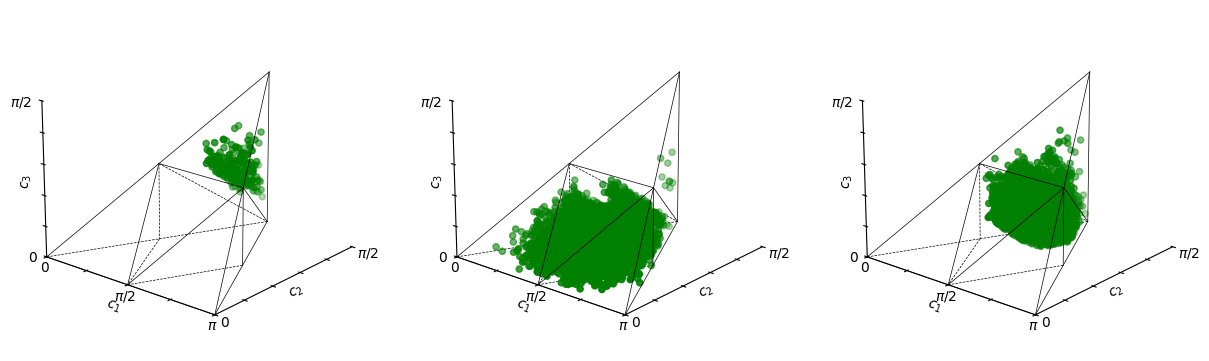

In [6]:
plt.close()

n = len(successes.keys())
_, axs = plt.subplots(
    1, n, subplot_kw={"projection": "3d", "computed_zorder": False}, figsize=(n * 5, 5)
)
for idx, ax in zip(successes.keys(), axs):
    w = WeylChamber()
    w.labels = {}
    w.render(ax)
    if len(successes[idx]) > 0:
        w.ax.scatter3D(
            *zip(*[c1c2c3(g) for g in successes[idx]]), color="green", zorder=-1
        )
    if len(false_negatives[idx]) > 0:
        w.ax.scatter3D(
            *zip(*[c1c2c3(g) for g in false_negatives[idx]]), color="red", zorder=-1
        )
    if len(false_positives[idx]) > 0:
        w.ax.scatter3D(
            *zip(*[c1c2c3(g) for g in false_positives[idx]]), color="yellow", zorder=-1
        )